# Optimal Experimental Design DAE

To do parameter estimation, we use yeast growth model from previous [example](<../Simulation DAE>).
For OED we need a model and selected strategy for OED.

## Model creation

In [134]:
import mopeds
import numpy as np
import matplotlib.pyplot as plt

def create_model():
    variable_list = mopeds.variables.VariableList()
    
    variable_list.add_variable(mopeds.VariableState("x1", 10, 0, 10))
    variable_list.add_variable(mopeds.VariableState("x2", 0.01))
    variable_list.add_variable(mopeds.VariableAlgebraic("r", 1.7))
    variable_list.add_variable(mopeds.VariableControlPiecewiseConstant("u1", 0.15, 0.05, 0.2))
    variable_list.add_variable(mopeds.VariableControlPiecewiseConstant("u2", 5, 5, 35))
    
    variable_list.add_variable(mopeds.VariableParameter("theta1", 0.180, 1e-2, 2))
    variable_list.add_variable(mopeds.VariableParameter("theta2", 0.180, 1e-2, 20))
    variable_list.add_variable(mopeds.VariableParameter("theta3", 0.550, 1e-2, 2))
    variable_list.add_variable(mopeds.VariableParameter("theta4", 0.050, 1e-2, 2))
    
    m = mopeds.Model(variable_list)
    
    x1 = m.varlist_all["x1"].casadi_var
    x2 = m.varlist_all["x2"].casadi_var
    r = m.varlist_all["r"].casadi_var
    u1 = m.varlist_all["u1"].casadi_var
    u2 = m.varlist_all["u2"].casadi_var
    
    theta1 = m.varlist_all["theta1"].casadi_var
    theta2 = m.varlist_all["theta2"].casadi_var
    theta3 = m.varlist_all["theta3"].casadi_var
    theta4 = m.varlist_all["theta4"].casadi_var
    
    eq_alg1 = r - (theta1 * x2 / (theta2 + x2))
    
    eq1 = (r - u1 - theta4)  * x1
    eq2 = - (r * x1 / theta3) + u1 * (u2 - x2)
    
    m.add_equations_differential([eq1, eq2])
    m.add_equations_algebraic([eq_alg1])
    
    return variable_list, m

## Specifying OED problem

In the article under revision we categorize OED optimization of dynamic models using: 4 different *OED Strategies* based on the set of decision variables and 3 *Sampling Strategies*: Adaptive Sampling (AS), Optimal Sampling (OS) and Adaptive Optimal Sampling (AOS).

### Strategy I
Strategy I allows OED to choose initial values of state variables and control variables. Controls cannot be changed during the experiment, time and number of measurements is given by experimenter.

In [135]:
oed_settings = mopeds.FixedGridSampling()
oed_settings.num_control_switches = 0

variable_list, m = create_model()
time_grid = np.linspace(0,20,21)

variable_list["x1"].fixed = False
variable_list["u1"].fixed = False
variable_list["u1"].ignore_plotting = False
variable_list["u2"].fixed = False
variable_list["u2"].ignore_plotting = False

variable_list["theta1"].fixed = False

oed = mopeds.OptimalExperimentalDesign(m, [variable_list], time_grid, settings=oed_settings)
oed.solver_settings["ipopt"]["max_iter"] = 40
oed.solver_settings["ipopt"]["print_level"] = 0
oed.solver_settings["print_time"] = False
res_oed = oed.optimize()

#### Result analysis

Plotting of the results of the OED is a complex tasks. Below there is an example, on how one can use optimized sampling and switching times to plot results. Depending on selected OED and sampling strategies one might need a different approach.

Blue points in a first graph show times, at which measurements have to be taken. **CAUTION**: 

Strategy I, objective function: 2.54665e-05


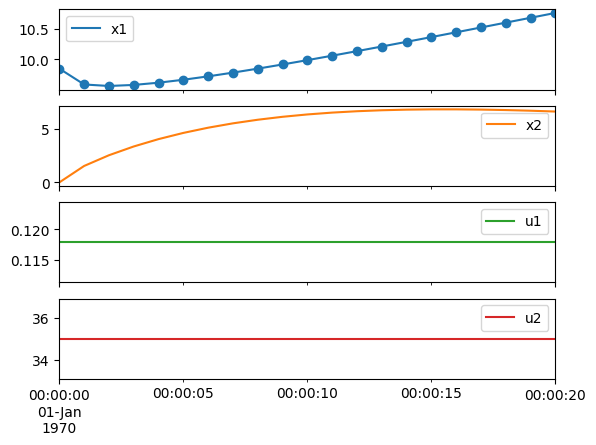

In [136]:
print(f"Strategy I, objective function: {res_oed["f"]}")
res_sim_oed = oed.generate_experimental_data(res_oed["x_dict"])
axis = res_sim_oed.plot(show=False)
axis[0].scatter(x=res_sim_oed["x1"].time_absolute, y=res_sim_oed["x1"].value)
plt.show()

### Strategy II

In Strategy II controls are constant over the experiment as in Strategy I, however, OED is allowed to select a time at which samples have to be taken. Strategy II and IV can be solved using 3 different sampling streategies. As a rule of thumb -> use AS when number of samples is low, otherwise use OS.

For Strategy II user doesn't specify a sampling time grid, but need to set a length of experiment, sampling delay and number of samples.

**CAUTION**: results of OED are dependent on guess and parameter values itself!

Strategy II, objective function: 1.54734e-05


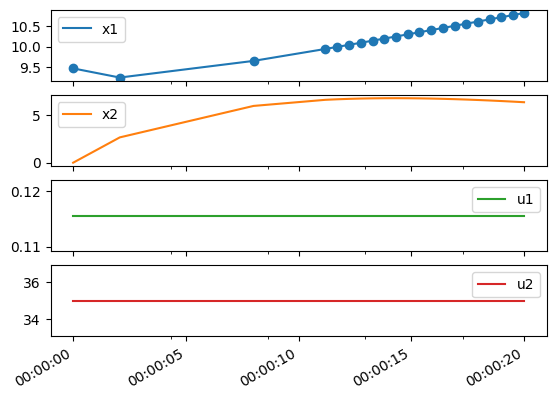

In [137]:
oed_settings = mopeds.AdaptiveSampling()
oed_settings.max_time_experiment = 20
oed_settings.num_control_switches = 0
oed_settings.num_sampling_times = 20
oed_settings.min_sampling_delay = 0.5

variable_list, m = create_model()

variable_list["x1"].fixed = False
variable_list["u1"].fixed = False
variable_list["u1"].ignore_plotting = False
variable_list["u2"].fixed = False
variable_list["u2"].ignore_plotting = False

variable_list["theta1"].fixed = False

oed = mopeds.OptimalExperimentalDesign(m, [variable_list], settings=oed_settings)
oed.solver_settings["ipopt"]["max_iter"] = 40
oed.solver_settings["ipopt"]["print_level"] = 0
oed.solver_settings["print_time"] = False
res_oed = oed.optimize()
print(f"Strategy II, objective function: {res_oed["f"]}")

res_sim_oed = oed.generate_experimental_data(res_oed["x_dict"])
axis = res_sim_oed.plot(show=False)
axis[0].scatter(x=res_sim_oed["x1"].time_absolute, y=res_sim_oed["x1"].value)
plt.show()

### Strategy III

Same as Strategy I, however, controls can be changed during experiment. Sampling grid is fixed, however, number of control switches is changed to 1.

**CAUTION**: Streategy II is not always more optimal than III, as in the given example.

Strategy III, objective function: 2.03409e-05


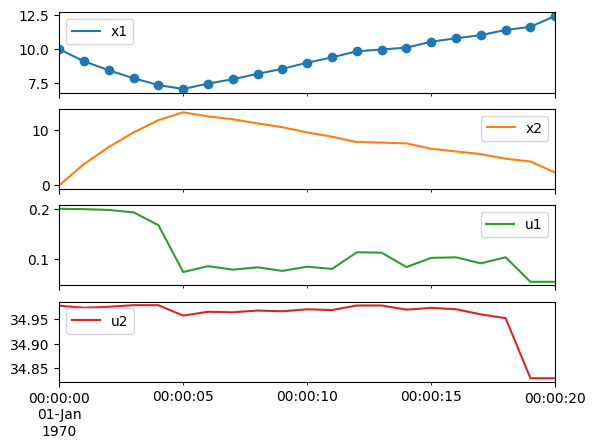

In [138]:
oed_settings = mopeds.FixedGridSampling()
oed_settings.num_control_switches = 1

variable_list, m = create_model()
time_grid = np.linspace(0,20,21)

variable_list["x1"].fixed = False
variable_list["u1"].fixed = False
variable_list["u1"].ignore_plotting = False
variable_list["u2"].fixed = False
variable_list["u2"].ignore_plotting = False

variable_list["theta1"].fixed = False

oed = mopeds.OptimalExperimentalDesign(m, [variable_list], time_grid, settings=oed_settings)
oed.solver_settings["ipopt"]["max_iter"] = 40
oed.solver_settings["ipopt"]["print_level"] = 0
oed.solver_settings["print_time"] = False
res_oed = oed.optimize()
print(f"Strategy III, objective function: {res_oed["f"]}")

res_sim_oed = oed.generate_experimental_data(res_oed["x_dict"])
axis = res_sim_oed.plot(show=False)
axis[0].scatter(x=res_sim_oed["x1"].time_absolute, y=res_sim_oed["x1"].value)
plt.show()

### Strategy IV

Strategy IV is a combination of all strategies. OED decides on sampling grid and can change controls over time. Strategy IV should yield the most "informative" experimental design. 

**CAUTION**: x1 doesn't jump from 10 to 6 at the beginning of the experiment as shown in graph. It's just an artifact of the simulator evaluating only at sampling times.

Strategy IV, objective function: 1.16034e-05


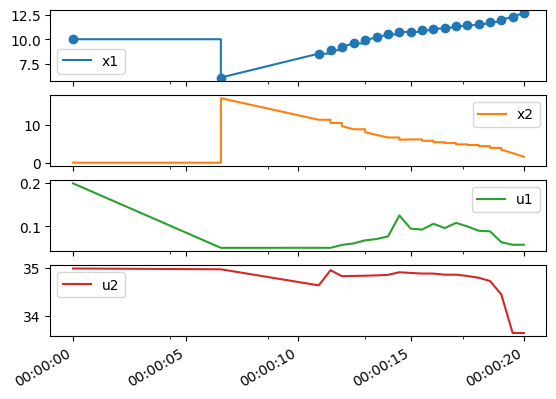

In [139]:
oed_settings = mopeds.AdaptiveSampling()
oed_settings.max_time_experiment = 20
oed_settings.num_control_switches = 1
oed_settings.num_sampling_times = 20
oed_settings.min_sampling_delay = 0.5

variable_list, m = create_model()

variable_list["x1"].fixed = False
variable_list["u1"].fixed = False
variable_list["u1"].ignore_plotting = False
variable_list["u2"].fixed = False
variable_list["u2"].ignore_plotting = False

variable_list["theta1"].fixed = False

oed = mopeds.OptimalExperimentalDesign(m, [variable_list], settings=oed_settings)
oed.solver_settings["ipopt"]["max_iter"] = 40
oed.solver_settings["ipopt"]["print_level"] = 0
oed.solver_settings["print_time"] = False
res_oed = oed.optimize()
print(f"Strategy IV, objective function: {res_oed["f"]}")

res_sim_oed = oed.generate_experimental_data(res_oed["x_dict"])
axis = res_sim_oed.plot(show=False)
axis[0].scatter(x=res_sim_oed["x1"].time_absolute, y=res_sim_oed["x1"].value)
plt.show()